# Grazing Donkey

Ссылка на задачу https://www.codewars.com/kata/5b5ce2176d0db7331f0000c0 
Прошу ознакомиться с условием прежде чем читать решение

## Математика

Создадим изображение к условию задачи чтобы понять что тут вообще нужно делать.

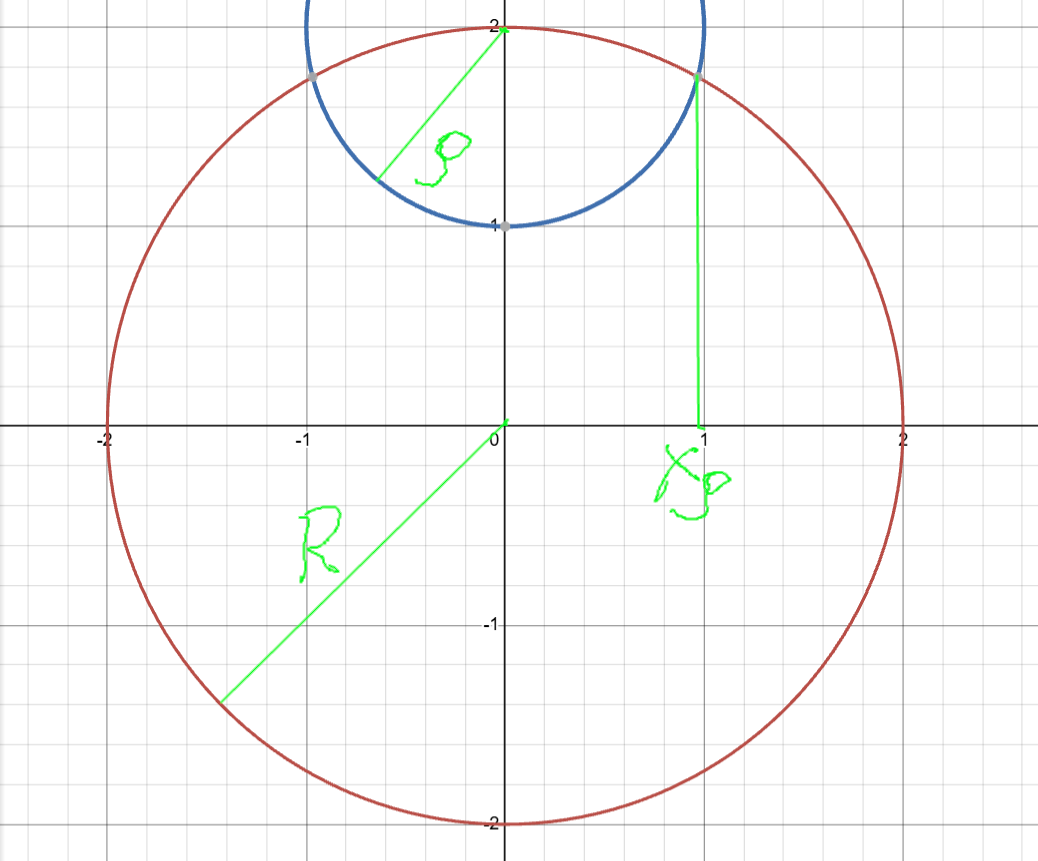

$R = \frac{D}2$ - радиус поля, $r$ - радиус верёвки, $x_{\rho}$ - точка пересечения окружностей.

Из курса математического анализа известно, что площадь криволинейной трапеции находится через определённый интеграл. Найдём функции, которые ограничивают трапеции

Уравнение окружности радиуса $R$ (в данном случае поля)

$$
y_1 (x) =\sqrt{R^2 - x^2}
$$

Фигура в любом случае будет ограничена верхней дугой, поэтому оствляем знак +.

Уравнение окружности радиуса $r$

$$
y_2(x) = R - \sqrt{r^2-x^2}
$$

Перед корнем минус потому что это нижняя полуокружность

Запишем площадь полученной фигуры

$$
S_\rho = 2 \int \limits_0^{x_\rho}(\sqrt{R^2 - x^2} - R + \sqrt{r^2-x^2}) dx 
$$

Найдём неопределённый интеграл от корня в общем случае

$$
I_{r}(\rho, x) = \int \sqrt{\rho^2-x^2} \, dx = \frac12 (x \sqrt{\rho^2-x^2} + \rho^2 \arctan(\frac{x}{\sqrt{\rho^2-x^2}}))
$$

Тогда

$$
S_{\rho} = (I_r(R) - 2Rx + I_r(r))|_0^{x_\rho}
$$

Тут мы рассмотрели только случай, когда дуга поля пересекается в верхней полуокружности. Чтобы получить всю площадь введём так казываемую добавочную площадь с пределами от точки пересечения двух дуг до пересечения окружности поля с точкой $y=0$

Выражается эта площадь следующим образом

$$
S_+ = \frac{\pi}2 R^2 - I(R, x_{\rho})
$$

Очевидно, что добовлять эту функцию нужно тогда когда $\frac{r}R = \sqrt2$

Далее составим уравнение 

$$
\frac{S_{\rho} + S_+}{\pi R^2} = p
$$

Где p - вероятность из условия

Преобразуем уравнение

$$
f(\rho) = S_{\rho} + S_+ - p R^2 \pi
$$

Найдём точку пересечения приравняв $y_1$ и $y_2$. 

$$
\sqrt{R^2 - x^2} = R - \sqrt{r^2-x^2}
$$

Я не буду описывать решение уравнения, однако отмечу, что в подобных уравнениях обязательно надо возводить в квадрат, поэтому не имеет значение приравниваем ли мы верхнюю полуокружность в уравнении поля

Решая, получим

$$
x_r = \frac{\sqrt{4 r^2 R^2 - r^4}}{2R}
$$

Далее введём новую переменную - удельный радиус.

$$
\rho = \frac{r}D
$$

Введём несколько новых функций для удобства. Я решил их ввести по ходу решения просто потому что

$$
\begin{align}
x(\rho) = \rho \sqrt{1-\rho^2} \\
f_1(x, \rho) = \sqrt{\rho^2-x^2}
\end{align}
$$

Тогда точка пересечения 

$$
x(\rho) = \rho \sqrt{1-\rho^2}
$$

Выпишем каждый интеграл с этими переменными

Интеграл от дуги поля

$$
\frac{I(R)}2 = R^2 (2x(\rho) * \sqrt{1 - 4x^2(\rho)} + \arctan{\frac{2x(\rho)}{\sqrt{1 - 4x^2(\rho)}}}) =
\frac{i(R)}2 R^2
$$

От окружности радиуса r

$$
\frac{I(\rho)}2 = R^2(4 x(\rho) \rho^2 + \arctan{\frac{x(\rho)}{\rho^2}}) = \frac{i(\rho)}2 R^2
$$

Добавочная площадь

$$
S_+ = \frac{R^2}2(\pi - i(R))
$$

Тогда 

$$
f_{\rho} = (i(R) + i(\rho) - 4x(\rho) + 2S_+) R^2
$$

Чтобы найти искомый удельный радиус приравняем функцию к 0

$$
(i(R) + i(\rho) - 4x(\rho) + 2S_+) R^2 = 0
$$

В итоге получаем

$$
i(R) + i(\rho) - 4x(\rho) + 2S_+ = 0
$$

Далее необходимо решить уравнение численно. Я выбрал метод бисекции, описывать далее я это не буду, укажу в коде

Уравнение

$$
\begin{align}
\frac{S_d(r)}{\pi R^2} = p \\
S_d(r) - \pi R^2 p = 0 
\end{align}
$$

## Код функции

In [87]:
def get_rope_length(field_diameter, eaten_ratio):
    Pk = (3**0.5 / math.pi + 1/3) / 2

    if field_diameter == 0 or eaten_ratio == 0:
        return 0

    if eaten_ratio == 1:
        return field_diameter
    
    x_rho = lambda rho: rho * (1 - rho**2)**0.5
    i_R = lambda rho: 2 * x_rho(rho) * (1 - 4 * x_rho(rho)**2)**0.5 + math.atan(2 * x_rho(rho) / (1 - 4 * x_rho(rho)**2)**0.5)
    i_r = lambda rho: 4 * x_rho(rho) * rho**2 + 4 * rho**2 * math.atan(x_rho(rho) / rho**2) 
    s_plus = lambda rho: math.pi / 2 - i_R(rho) if rho > 1/2**0.5 else 0
    s = lambda rho: i_r(rho) + i_R(rho) - 4 * x_rho(rho) + 2 * s_plus(rho)
    equ = lambda rho: s(rho) - math.pi * eaten_ratio

    xl = 0.001
    xr = 1

    for _ in range(10):
        xm = (xr - xl) / 2
        xi = xl + xm
        if equ(xl) * equ(xi) < 0:
            xr = xi
        else:
            xl = xi

    return math.floor(xi * field_diameter)

In [88]:
get_rope_length(10, 1)

10